## Testing the mirror-image hypothesis: underreaction to performance quality

Every notebook so far tested *overreaction* and found none. But the standard behavioral prediction actually points the other way: markets are expected to price the scoreline (salient, easy to process) reasonably well, and to **underreact** to performance quality that didn't show up on the scoreboard (a team that generated a lot of chances but didn't convert). This notebook tests that mirror-image hypothesis directly: does a team's **performance_gap** &mdash; how much better or worse they did on xG than the actual goal margin &mdash; predict a *later* drift in their title odds, beyond the market's immediate reaction to the result itself?

If the market underreacts to quality: teams that "deserved better" than their scoreline (dominated on xG but didn't get the goals) should see their title odds keep grinding *up* afterward, as the market slowly catches up to information it underweighted. If the market handles this fine, `performance_gap` shouldn't predict anything once the immediate reaction to the result is accounted for.

This reuses three things already built: the SofaScore xG join from `regression_analysis.ipynb`, and the Kalshi-internal team crosswalk + price-window/next-match-cap machinery from `tournament_futures_analysis.ipynb`. Unlike that notebook, this one uses **every team-match, not just wins** (208 team-match rows instead of 75 win events), which directly addresses that notebook's power problem.

### Method

For each of the 208 team-match observations (104 matches &times; 2 teams):

- **`goal_margin`** = team's goals &minus; opponent's goals (the result)
- **`xg_margin`** = team's xG &minus; opponent's xG (the underlying performance)
- **`performance_gap`** = `xg_margin - goal_margin` &mdash; positive means the team generated more chances than their scoreline reflects (deserved better, "unlucky"); negative means the scoreline flatters them ("lucky")

Same title-odds checkpoints as `tournament_futures_analysis.ipynb`, relative to the match's `close_time`: `pre` (&minus;4h), `post` (+2h, the market's immediate reaction to the result), `later` (+48h, capped to never cross the team's next match &mdash; same safety check as before).

- **`jump`** = `post - pre` &mdash; the immediate reaction.
- **`drift`** = `later - post` &mdash; what happens afterward. This is the one that tests underreaction.

**Caveat, same shape as the one in `calibration_analysis.ipynb`:** the two rows from the same match aren't independent observations (team A's `goal_margin` is essentially `-1 ×` team B's), so standard errors here are a bit too optimistic. Worth a clustered-by-match correction before leaning hard on the exact p-values.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

# Notebook lives in code/, so data/ and output/ live one level up.
ROOT = Path.cwd().parent
FIG_DIR = ROOT / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEAM_NAME_ALIASES = {
    "Cape Verde": "Cabo Verde",
    "Bosnia and Herzegovina": "Bosnia & Herzegovina",
    "Congo DR": "DR Congo",
    "Ivory Coast": "C\u00f4te d'Ivoire",
    "IR Iran": "Iran",
    "Turkiye": "T\u00fcrkiye",
    "Curacao": "Cura\u00e7ao",
    "Korea Republic": "South Korea",
}
REVERSE_ALIASES = {v: k for k, v in TEAM_NAME_ALIASES.items()}
FUTURES_ALIASES = {"Korea Republic": "South Korea", "Turkiye": "Turkey", "IR Iran": "Iran"}
PRE_H, POST_H, LATER_H = 4, 2, 48

In [2]:
def price_at(grp: pd.DataFrame, target_ts: pd.Timestamp) -> float:
    before = grp[grp["timestamp"] <= target_ts]
    return before["price_close"].iloc[-1] if len(before) else np.nan


In [3]:
markets = pd.read_parquet(ROOT / "data/kalshi/kxwcgame_markets.parquet")
futures_markets = pd.read_parquet(ROOT / "data/kalshi/kxmenworldcup_markets.parquet")
futures_candles = pd.read_parquet(ROOT / "data/kalshi/candlesticks/kxmenworldcup_hourly.parquet")
schedule = pd.read_parquet(ROOT / "data/sofascore/schedule.parquet")
sofa_stats = pd.read_parquet(ROOT / "data/sofascore/statistics.parquet")

xg = sofa_stats[(sofa_stats["period"] == "ALL") & (sofa_stats["stat_name"] == "Expected goals")]
before = len(schedule)
sched = schedule.merge(xg[["event_id", "home_value", "away_value"]], on="event_id", how="left")
print(f"schedule merge xg: {before} rows -> {len(sched)} rows")
sched = sched.rename(columns={"home_value": "home_xg", "away_value": "away_xg"})

home_rows = sched[["event_id", "home_team", "away_team", "home_score", "away_score", "home_xg", "away_xg"]].rename(
    columns={"home_team": "team", "away_team": "opponent", "home_score": "team_goals", "away_score": "opp_goals",
             "home_xg": "team_xg", "away_xg": "opp_xg"}
)
away_rows = sched[["event_id", "away_team", "home_team", "away_score", "home_score", "away_xg", "home_xg"]].rename(
    columns={"away_team": "team", "home_team": "opponent", "away_score": "team_goals", "home_score": "opp_goals",
             "away_xg": "team_xg", "home_xg": "opp_xg"}
)
team_match = pd.concat([home_rows, away_rows], ignore_index=True)
team_match["goal_margin"] = team_match["team_goals"] - team_match["opp_goals"]
team_match["xg_margin"] = team_match["team_xg"] - team_match["opp_xg"]
team_match["performance_gap"] = team_match["xg_margin"] - team_match["goal_margin"]
print(f"team-match rows: {len(team_match)}")

schedule merge xg: 104 rows -> 104 rows
team-match rows: 208


In [4]:
markets["close_time"] = pd.to_datetime(markets["close_time"])
parts = markets["event_title"].str.split(" vs ", n=1, expand=True)
markets["team1_kalshi"] = parts[0].str.strip()
markets["team2_kalshi"] = parts[1].str.split(":").str[0].str.strip()
markets["team_set"] = [
    frozenset(t)
    for t in zip(markets["team1_kalshi"].replace(TEAM_NAME_ALIASES), markets["team2_kalshi"].replace(TEAM_NAME_ALIASES))
]
match_close = markets[["event_ticker", "team_set", "close_time"]].drop_duplicates()

sched2 = schedule.copy()
sched2["team_set" ] = [frozenset(t) for t in zip(sched2["home_team"], sched2["away_team"])]
before = len(sched2)
sched2 = sched2.merge(match_close, on="team_set", how="left")
print(f"sched2 merge match_close: {before} rows -> {len(sched2)} rows")

before = len(team_match)
team_match = team_match.merge(sched2[["event_id", "event_ticker", "close_time"]], on="event_id", how="left")
print(f"team_match merge sched2: {before} rows -> {len(team_match)} rows")
team_match["team_kalshi"] = team_match["team"].map(lambda x: REVERSE_ALIASES.get(x, x))
team_match["team_kalshi_futures"] = team_match["team_kalshi"].map(lambda x: FUTURES_ALIASES.get(x, x))
before = len(team_match)
team_match = team_match.merge(
    futures_markets[["team_subtitle", "market_ticker"]].rename(columns={"market_ticker": "futures_ticker"}),
    left_on="team_kalshi_futures", right_on="team_subtitle", how="left",
)
print(f"team_match merge futures_markets: {before} rows -> {len(team_match)} rows")
print(f"unmatched to Kalshi event/futures market: {team_match['event_ticker'].isna().sum()} / {team_match['futures_ticker'].isna().sum()}")

tm_sorted = team_match[["team_kalshi", "close_time"]].drop_duplicates().sort_values(["team_kalshi", "close_time"])
tm_sorted["next_close_time"] = tm_sorted.groupby("team_kalshi")["close_time"].shift(-1)
before = len(team_match)
team_match = team_match.merge(tm_sorted, on=["team_kalshi", "close_time"], how="left")
print(f"team_match merge tm_sorted: {before} rows -> {len(team_match)} rows")

sched2 merge match_close: 104 rows -> 104 rows
team_match merge sched2: 208 rows -> 208 rows
team_match merge futures_markets: 208 rows -> 208 rows
unmatched to Kalshi event/futures market: 0 / 0
team_match merge tm_sorted: 208 rows -> 208 rows


In [5]:
candles_by_ticker = {t: g.sort_values("timestamp") for t, g in futures_candles.groupby("market_ticker")}


rows = []
for r in team_match.itertuples():
    grp = candles_by_ticker.get(r.futures_ticker)
    if grp is None or pd.isna(r.futures_ticker) or pd.isna(r.close_time):
        continue
    later_ts = r.close_time + pd.Timedelta(hours=LATER_H)
    if pd.notna(r.next_close_time) and r.next_close_time <= later_ts:
        continue
    pre = price_at(grp, r.close_time - pd.Timedelta(hours=PRE_H))
    post = price_at(grp, r.close_time + pd.Timedelta(hours=POST_H))
    later = price_at(grp, later_ts)
    if any(pd.isna(x) for x in (pre, post, later)):
        continue
    rows.append(
        {
            "team": r.team, "close_time": r.close_time,
            "goal_margin": r.goal_margin, "xg_margin": r.xg_margin, "performance_gap": r.performance_gap,
            "jump": post - pre, "drift": later - post,
        }
    )

reactions = pd.DataFrame(rows)
for col in ["goal_margin", "xg_margin", "performance_gap"]:
    reactions[f"{col}_z"] = (reactions[col] - reactions[col].mean()) / reactions[col].std()
print(f"usable team-match observations: {len(reactions)} / {len(team_match)}")

usable team-match observations: 153 / 208


In [6]:
model_jump = smf.ols("jump ~ goal_margin_z + xg_margin_z", data=reactions).fit()
print(model_jump.summary())

                            OLS Regression Results                            
Dep. Variable:                   jump   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     7.925
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           0.000535
Time:                        21:04:42   Log-Likelihood:                 201.85
No. Observations:                 153   AIC:                            -397.7
Df Residuals:                     150   BIC:                            -388.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0008      0.005      0.156

In [7]:
model_drift = smf.ols("drift ~ goal_margin_z + xg_margin_z", data=reactions).fit()
print(model_drift.summary())

                            OLS Regression Results                            
Dep. Variable:                  drift   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.275
Date:                Sun, 30 Aug 2026   Prob (F-statistic):              0.106
Time:                        21:04:42   Log-Likelihood:                 554.46
No. Observations:                 153   AIC:                            -1103.
Df Residuals:                     150   BIC:                            -1094.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.0013      0.001     -2.381

In [8]:
r_gap, p_gap = stats.pearsonr(reactions["performance_gap"], reactions["drift"])
print(f"performance_gap vs. drift (all n={len(reactions)}): r={r_gap:+.3f}, p={p_gap:.3f}")

nontrivial = reactions[reactions["jump"].abs() > 0.01]
r_nt, p_nt = stats.pearsonr(nontrivial["performance_gap"], nontrivial["drift"])
print(f"performance_gap vs. drift (nontrivial-jump subset, n={len(nontrivial)}): r={r_nt:+.3f}, p={p_nt:.3f}")

performance_gap vs. drift (all n=153): r=-0.075, p=0.358
performance_gap vs. drift (nontrivial-jump subset, n=48): r=-0.249, p=0.088


Saved /Users/katemarine/Documents/wc26-prediction-markets/output/figures/underreaction_test.png


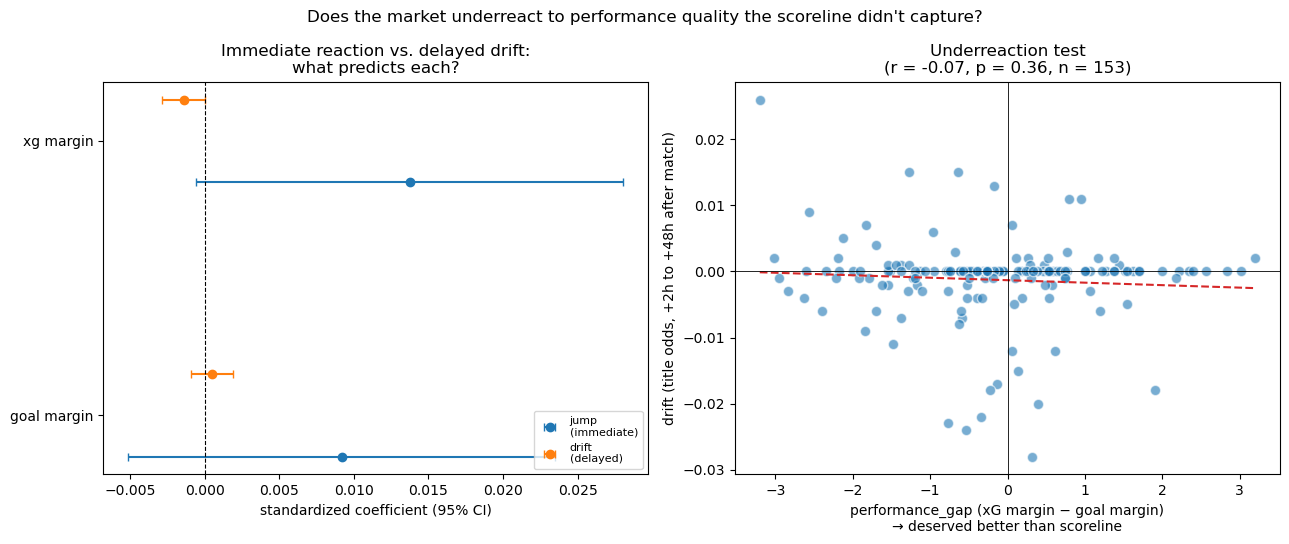

In [9]:
fig, (ax_coef, ax_scatter) = plt.subplots(1, 2, figsize=(13, 5.5))

coef_rows = []
for model_name, model in [("jump\n(immediate)", model_jump), ("drift\n(delayed)", model_drift)]:
    ci = model.conf_int()
    for predictor in ["goal_margin_z", "xg_margin_z"]:
        coef_rows.append(
            {"model": model_name, "predictor": predictor.replace("_z", "").replace("_", " "),
             "coef": model.params[predictor], "ci_low": ci.loc[predictor, 0], "ci_high": ci.loc[predictor, 1]}
        )
coef_df = pd.DataFrame(coef_rows)

models = coef_df["model"].unique()
offsets = np.linspace(-0.15, 0.15, len(models))
predictors = coef_df["predictor"].unique()
y_base = {p: i for i, p in enumerate(predictors)}
for model_name, off in zip(models, offsets):
    sub = coef_df[coef_df["model"] == model_name]
    y = [y_base[p] + off for p in sub["predictor"]]
    err = [sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]]
    ax_coef.errorbar(sub["coef"], y, xerr=err, fmt="o", capsize=3, label=model_name)
ax_coef.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax_coef.set_yticks(list(y_base.values()))
ax_coef.set_yticklabels(list(y_base.keys()))
ax_coef.set_xlabel("standardized coefficient (95% CI)")
ax_coef.set_title("Immediate reaction vs. delayed drift:\nwhat predicts each?")
ax_coef.legend(fontsize=8, loc="lower right")

ax_scatter.scatter(reactions["performance_gap"], reactions["drift"], alpha=0.6, edgecolor="white", s=55)
z = np.polyfit(reactions["performance_gap"], reactions["drift"], 1)
xs = np.linspace(reactions["performance_gap"].min(), reactions["performance_gap"].max(), 50)
ax_scatter.plot(xs, np.polyval(z, xs), color="tab:red", linestyle="--", linewidth=1.5)
ax_scatter.axhline(0, color="black", linewidth=0.6)
ax_scatter.axvline(0, color="black", linewidth=0.6)
ax_scatter.set_xlabel("performance_gap (xG margin \u2212 goal margin)\n→ deserved better than scoreline")
ax_scatter.set_ylabel("drift (title odds, +2h to +48h after match)")
ax_scatter.set_title(f"Underreaction test\n(r = {r_gap:+.2f}, p = {p_gap:.2f}, n = {len(reactions)})")

fig.suptitle("Does the market underreact to performance quality the scoreline didn't capture?")
fig.tight_layout()
out_path = FIG_DIR / "underreaction_test.png"
fig.savefig(out_path, dpi=150)
print(f"Saved {out_path}")

### Results so far

**No evidence of underreaction. If anything, a weak, non-significant hint pointing the opposite way.**

The primary test &mdash; `performance_gap` predicting subsequent title-odds `drift`, across all 153 usable team-match observations &mdash; found essentially nothing: r = -0.07, p = 0.36. Restricting to the 48 observations with a real immediate reaction (|jump| > 0.01, the same "nontrivial" filter used in the goal-level notebooks) sharpens the correlation somewhat but not into significance: r = -0.25, p = 0.09. Note the **sign**: it's negative both times, meaning if there's anything here at all, teams who "deserved better" than their scoreline saw their title odds drift very slightly *down* afterward, not up &mdash; the opposite of the underreaction prediction, though far too weak and imprecise to call a real effect.

The two-model decomposition (left panel) tells a consistent story: for the **immediate** reaction (`jump`), both `goal_margin` and `xg_margin` point positive, and `xg_margin` is marginally the stronger of the two (p = 0.06) &mdash; a mild difference from `regression_analysis.ipynb`'s within-match finding that goal margin dominates xG outright; title odds seem to weigh underlying quality a bit more than a single match's own price movement does. For the **delayed** reaction (`drift`), the pattern flips: `xg_margin`'s coefficient goes slightly *negative* (marginal, p = 0.054) while `goal_margin` is flat. Read generously, that's a faint mean-reversion signal on the performance-quality component, not the sustained catch-up drift underreaction would predict.

**Bottom line for the report:** you now have two behavioral hypotheses tested head-to-head &mdash; overreaction (across four notebooks, using minute-level goal reactions and match-level calibration) and underreaction (here, using cross-match title-odds drift) &mdash; and neither found a real effect. That's a stronger, more complete claim than either result alone: this market doesn't show a clean directional bias in *either* direction, at least not one this data can detect.

**Limitations / next steps:**

- The same non-independence caveat as `calibration_analysis.ipynb` applies here too (two rows per match, not fully independent) &mdash; a match-clustered standard error would be the honest next step before trusting the exact p-values.
- n = 153 (48 with a real reaction) is still a single-tournament sample. Idea 3 from the report-scoping discussion &mdash; checking whether this null result holds up across attention/liquidity/tournament-stage subgroups &mdash; would be a natural way to stress-test it further.
- This only tests xG-vs-goals as the "underweighted" signal. Other performance dimensions not captured by score or xG (dominant possession without cutting through, a keeper standing on his head) could in principle be underreacted to even if xG isn't &mdash; worth keeping in mind as a scope limitation, not a disproof of underreaction generally.